## Exploratory Data Analysis (EDA)

**Research Question:** How does disaster type, scale, and geography relate to the economic impact of storm events in the United States?

**Dataset:** NOAA Storm Events — yearly CSV files from 1950 onwards, covering property damage, crop damage, injuries, deaths, and event metadata across all U.S. states.

**EDA Workflow:**
1. Data Cleaning & Preparation
2. Summary Statistics
3. Univariate Analysis — damage distributions
4. Bivariate Analysis — damage by event type; frequency vs. damage
5. Regional Analysis — damage severity by state
6. Multivariate Analysis — combined damage factors (heatmap)
7. Time Series Analysis — event frequency over time
8. Summary & Hypotheses

In [1]:
import pandas as pd
import glob

# Define the directory where the data files are located
data_directory = 'DataForProject/'

# Use glob to find all CSV files in the specified directory
csv_files = glob.glob(f"{data_directory}*.csv")

# Initialize an empty list to store individual DataFrames
df_list = []

# Loop through each CSV file and read it into a DataFrame
for file in csv_files:
    try:
        df = pd.read_csv(file, low_memory=False)
        df_list.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all DataFrames into a single DataFrame
if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)
    print(f"Successfully loaded {len(csv_files)} files.")
    print(f"Shape: {combined_df.shape}")
    print(combined_df.head(3))
else:
    print("No CSV files found or could not be read.")

Successfully loaded 77 files.
Shape: (2019570, 51)
   BEGIN_YEARMONTH  BEGIN_DAY  BEGIN_TIME  END_YEARMONTH  END_DAY  END_TIME  \
0           195004         28        1445         195004       28      1445   
1           195004         29        1530         195004       29      1530   
2           195007          5        1800         195007        5      1800   

   EPISODE_ID  EVENT_ID         STATE  STATE_FIPS  ...  END_RANGE END_AZIMUTH  \
0         NaN  10096222      OKLAHOMA        40.0  ...        NaN         NaN   
1         NaN  10120412         TEXAS        48.0  ...        NaN         NaN   
2         NaN  10104927  PENNSYLVANIA        42.0  ...        NaN         NaN   

  END_LOCATION BEGIN_LAT  BEGIN_LON END_LAT END_LON EPISODE_NARRATIVE  \
0          NaN     35.12      -99.2   35.17  -99.20               NaN   
1          NaN     31.90      -98.6   31.73  -98.60               NaN   
2          NaN     40.58      -75.7   40.65  -75.47               NaN   

  EVENT_NARRAT

In [2]:
# Calculate percentage of missing values for each column
missing_percentage = (combined_df.isnull().sum() / len(combined_df)) * 100

# Identify columns with a high percentage of missing values (e.g., > 80%)
high_missing_cols = missing_percentage[missing_percentage > 80].index.tolist()

print(f"Columns to drop due to more than 80% missing values: {high_missing_cols}")

# Drop these columns from the DataFrame
combined_df_cleaned = combined_df.drop(columns=high_missing_cols)

print(f"Shape after dropping high missing columns: {combined_df_cleaned.shape}")

Columns to drop due to more than 80% missing values: ['FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME']
Shape after dropping high missing columns: (2019570, 42)


In [3]:
# Handle columns with very few missing values by dropping rows
# 'STATE', 'STATE_FIPS' each have only 1 missing value.
# 'DATA_SOURCE' has 15 missing values.
# Dropping these few rows will not significantly impact the dataset size.

initial_rows = combined_df_cleaned.shape[0]
combined_df_cleaned.dropna(subset=['STATE', 'STATE_FIPS', 'DATA_SOURCE'], inplace=True)

rows_after_drop = combined_df_cleaned.shape[0]
print(f"Dropped {initial_rows - rows_after_drop} rows due to missing values in STATE, STATE_FIPS, or DATA_SOURCE.")
print(f"Shape after dropping rows: {combined_df_cleaned.shape}")

Dropped 16 rows due to missing values in STATE, STATE_FIPS, or DATA_SOURCE.
Shape after dropping rows: (2019554, 42)


In [4]:
# Impute categorical columns: 'CZ_NAME' and 'WFO'
# 'CZ_NAME' has about 0.07% missing, 'WFO' has about 6.2% missing.
# We can fill these with a placeholder like 'Unknown' or with the mode.
# Using 'Unknown' is often safer as it doesn't introduce bias from mode imputation.

combined_df_cleaned['CZ_NAME'] = combined_df_cleaned['CZ_NAME'].fillna('UNKNOWN')
combined_df_cleaned['WFO'] = combined_df_cleaned['WFO'].fillna('UNKNOWN')

print("Missing values in CZ_NAME after imputation:", combined_df_cleaned['CZ_NAME'].isnull().sum())
print("Missing values in WFO after imputation:", combined_df_cleaned['WFO'].isnull().sum())

Missing values in CZ_NAME after imputation: 0
Missing values in WFO after imputation: 0


In [5]:
# Impute numerical damage columns: 'DAMAGE_PROPERTY' and 'DAMAGE_CROPS'
# These columns represent monetary damage. Missing values likely mean no damage (0).
combined_df_cleaned['DAMAGE_PROPERTY'] = combined_df_cleaned['DAMAGE_PROPERTY'].fillna(0)
combined_df_cleaned['DAMAGE_CROPS'] = combined_df_cleaned['DAMAGE_CROPS'].fillna(0)

print("Missing values in DAMAGE_PROPERTY after imputation:", combined_df_cleaned['DAMAGE_PROPERTY'].isnull().sum())
print("Missing values in DAMAGE_CROPS after imputation:", combined_df_cleaned['DAMAGE_CROPS'].isnull().sum())

Missing values in DAMAGE_PROPERTY after imputation: 0
Missing values in DAMAGE_CROPS after imputation: 0


In [6]:
# Impute 'SOURCE' and 'MAGNITUDE'
# 'SOURCE' is categorical/text. Fill with mode or 'UNKNOWN'.
# 'MAGNITUDE' is numerical. Fill with median or mean.

# For SOURCE, let's use the mode as it might represent the most common reporting source.
mode_source = combined_df_cleaned['SOURCE'].mode()[0]
combined_df_cleaned['SOURCE'] = combined_df_cleaned['SOURCE'].fillna(mode_source)

# For MAGNITUDE, let's use the median to be robust against outliers.
median_magnitude = combined_df_cleaned['MAGNITUDE'].median()
combined_df_cleaned['MAGNITUDE'] = combined_df_cleaned['MAGNITUDE'].fillna(median_magnitude)

print("Missing values in SOURCE after imputation:", combined_df_cleaned['SOURCE'].isnull().sum())
print("Missing values in MAGNITUDE after imputation:", combined_df_cleaned['MAGNITUDE'].isnull().sum())

Missing values in SOURCE after imputation: 0
Missing values in MAGNITUDE after imputation: 0


In [7]:
combined_df_cleaned['MAGNITUDE_TYPE'] = combined_df_cleaned['MAGNITUDE_TYPE'].fillna('UNKNOWN')
combined_df_cleaned['BEGIN_LOCATION'] = combined_df_cleaned['BEGIN_LOCATION'].fillna('UNKNOWN')
combined_df_cleaned['END_LOCATION'] = combined_df_cleaned['END_LOCATION'].fillna('UNKNOWN')
combined_df_cleaned['EPISODE_NARRATIVE'] = combined_df_cleaned['EPISODE_NARRATIVE'].fillna('NO NARRATIVE')
combined_df_cleaned['EVENT_NARRATIVE'] = combined_df_cleaned['EVENT_NARRATIVE'].fillna('NO NARRATIVE')

# For geographical coordinates (BEGIN_LAT, BEGIN_LON, END_LAT, END_LON),
# imputing with median is a reasonable approach for numerical data if dropping is not desired.
# These often have a significant number of missing values.

for col in ['BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON']:
    if col in combined_df_cleaned.columns:
        median_val = combined_df_cleaned[col].median()
        combined_df_cleaned[col] = combined_df_cleaned[col].fillna(median_val)

# For EPISODE_ID, which is an identifier, filling with a placeholder like -1 or mode
# can work if it's not going to be used as a unique key for joins.
# Let's fill with the mode, assuming missing IDs might follow a pattern.
mode_episode_id = combined_df_cleaned['EPISODE_ID'].mode()[0]
combined_df_cleaned['EPISODE_ID'] = combined_df_cleaned['EPISODE_ID'].fillna(mode_episode_id)

# Dropping columns with remaining high missing values
final_missing_cols_to_drop = ['BEGIN_RANGE', 'BEGIN_AZIMUTH', 'END_RANGE', 'END_AZIMUTH']
combined_df_cleaned = combined_df_cleaned.drop(columns=final_missing_cols_to_drop, errors='ignore')

print("Remaining missing values after cleaning steps:")
print(combined_df_cleaned.isnull().sum()[combined_df_cleaned.isnull().sum() > 0])
print(f"Shape after dropping additional missing columns: {combined_df_cleaned.shape}")

Remaining missing values after cleaning steps:
Series([], dtype: int64)
Shape after dropping additional missing columns: (2019554, 38)


In [8]:
# Convert 'BEGIN_DATE_TIME' and 'END_DATE_TIME' to datetime objects
# Using a common format to suppress the UserWarning and ensure consistent parsing.
# errors='coerce' will turn unparseable dates into NaT (Not a Time).
combined_df_cleaned['BEGIN_DATE_TIME'] = pd.to_datetime(combined_df_cleaned['BEGIN_DATE_TIME'], format='%m/%d/%Y %H:%M:%S', errors='coerce')
combined_df_cleaned['END_DATE_TIME'] = pd.to_datetime(combined_df_cleaned['END_DATE_TIME'], format='%m/%d/%Y %H:%M:%S', errors='coerce')

print("Data types after datetime conversion:")
print(combined_df_cleaned[['BEGIN_DATE_TIME', 'END_DATE_TIME']].dtypes)

Data types after datetime conversion:
BEGIN_DATE_TIME    datetime64[s]
END_DATE_TIME      datetime64[s]
dtype: object


Now, let's convert the `DAMAGE_PROPERTY` and `DAMAGE_CROPS` columns to numeric types. These columns often contain string representations with 'K' (thousands), 'M' (millions), or 'B' (billions) suffixes. We'll write a function to parse these strings and convert them into a consistent numerical format (float).

In [9]:
def parse_damage_value(value):
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        value = value.strip().upper()
        # Handle empty strings specifically before attempting to slice or convert
        if not value:
            return 0.0
        if value.endswith('K'):
            # Ensure there's a number before 'K'
            if value[:-1]: # Check if the string before 'K' is not empty
                return float(value[:-1]) * 1_000
            else:
                return 0.0
        elif value.endswith('M'):
            # Ensure there's a number before 'M'
            if value[:-1]:
                return float(value[:-1]) * 1_000_000
            else:
                return 0.0
        elif value.endswith('B'):
            # Ensure there's a number before 'B'
            if value[:-1]:
                return float(value[:-1]) * 1_000_000_000
            else:
                return 0.0
        try:
            return float(value)
        except ValueError:
            return 0.0 # Default to 0 for unparseable strings
    return 0.0 # Default to 0 for non-string, non-numeric values

combined_df_cleaned['DAMAGE_PROPERTY'] = combined_df_cleaned['DAMAGE_PROPERTY'].apply(parse_damage_value)
combined_df_cleaned['DAMAGE_CROPS'] = combined_df_cleaned['DAMAGE_CROPS'].apply(parse_damage_value)

print("Data types after damage value conversion:")
print(combined_df_cleaned[['DAMAGE_PROPERTY', 'DAMAGE_CROPS']].dtypes)

Data types after damage value conversion:
DAMAGE_PROPERTY    float64
DAMAGE_CROPS       float64
dtype: object


## Summary Statistics

With cleaning complete, we review the dataset's scope and the distributions of the primary numerical variables before visualizing.

In [10]:
year_series = combined_df_cleaned['BEGIN_DATE_TIME'].dt.year

if year_series.notna().any():
    year_min = int(year_series.min())
else:
    # Fallback: use YEAR and rebuild BEGIN_DATE_TIME so year_max calculation works below
    fallback_years = pd.to_numeric(combined_df_cleaned['YEAR'], errors='coerce')
    year_min = int(fallback_years.min())
    combined_df_cleaned['BEGIN_DATE_TIME'] = pd.to_datetime(
        fallback_years.astype('Int64').astype(str),
        format='%Y',
        errors='coerce'
    )
year_max = int(combined_df_cleaned['BEGIN_DATE_TIME'].dt.year.max())

print(f"Records:         {len(combined_df_cleaned):,}")
print(f"Date range:      {year_min} – {year_max}")
print(f"Unique event types: {combined_df_cleaned['EVENT_TYPE'].nunique()}")
print(f"States/territories: {combined_df_cleaned['STATE'].nunique()}")
print()

key_cols = ['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT',
            'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'MAGNITUDE']
display(combined_df_cleaned[key_cols].describe().round(2))

Records:         2,019,554
Date range:      1950 – 2026
Unique event types: 56
States/territories: 69



,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,MAGNITUDE
count,2019554.00,2019554.00,2019554.00,2019554.00,2.019554e+06,2.019554e+06,2019554.00
mean,0.08,0.01,0.01,0.00,2.980663e+05,3.502086e+04,32.56
std,3.58,1.79,0.59,0.09,2.956558e+07,2.440088e+06,26.45
min,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00
25%,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,1.75
50%,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,38.00
75%,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,50.00
max,1700.00,2400.00,638.00,56.00,1.790000e+10,1.500000e+09,22000.00


## Univariate Analysis

We start by examining the distributions of the two primary economic damage variables.

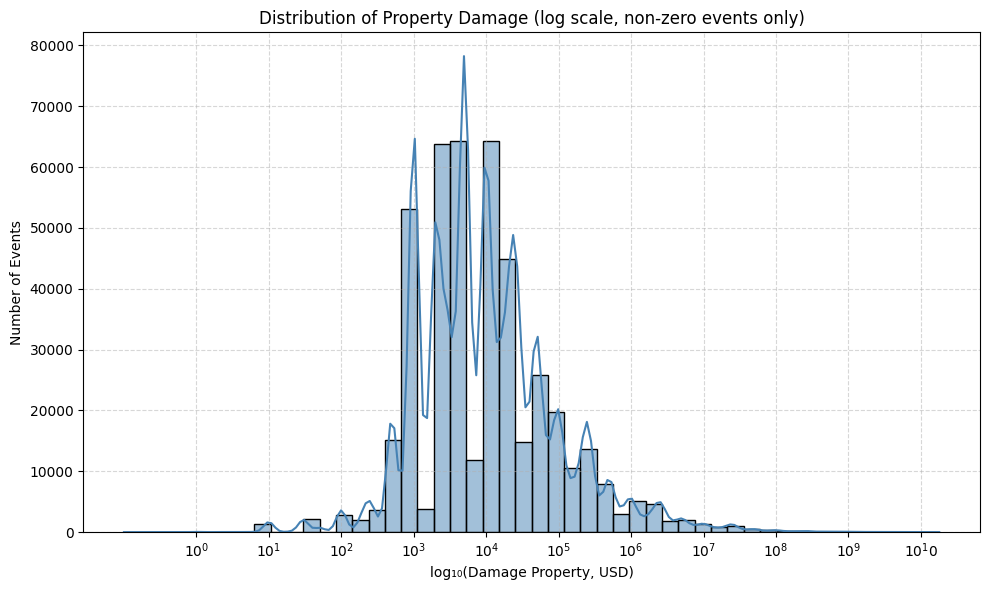

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter to non-zero values and apply log10 transform for a readable distribution
prop_nonzero = combined_df_cleaned[combined_df_cleaned['DAMAGE_PROPERTY'] > 0]['DAMAGE_PROPERTY']

plt.figure(figsize=(10, 6))
sns.histplot(np.log10(prop_nonzero), bins=50, kde=True, color='steelblue')
plt.title('Distribution of Property Damage (log scale, non-zero events only)')
plt.xlabel('log₁₀(Damage Property, USD)')
plt.ylabel('Number of Events')
plt.xticks(ticks=range(0, 11), labels=[f'$10^{i}$' for i in range(0, 11)])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Property damage** follows a roughly bimodal log-normal distribution, with a large cluster of low-cost events (around $10^3$–$10^4$, i.e. thousands of dollars) and a secondary cluster of major events reaching $10^8$–$10^{10}$. The long right tail is driven by rare catastrophic events — primarily hurricanes and major floods. The ~80% of events with $0 property damage are excluded here, confirming most storm events cause no structural impact at all.

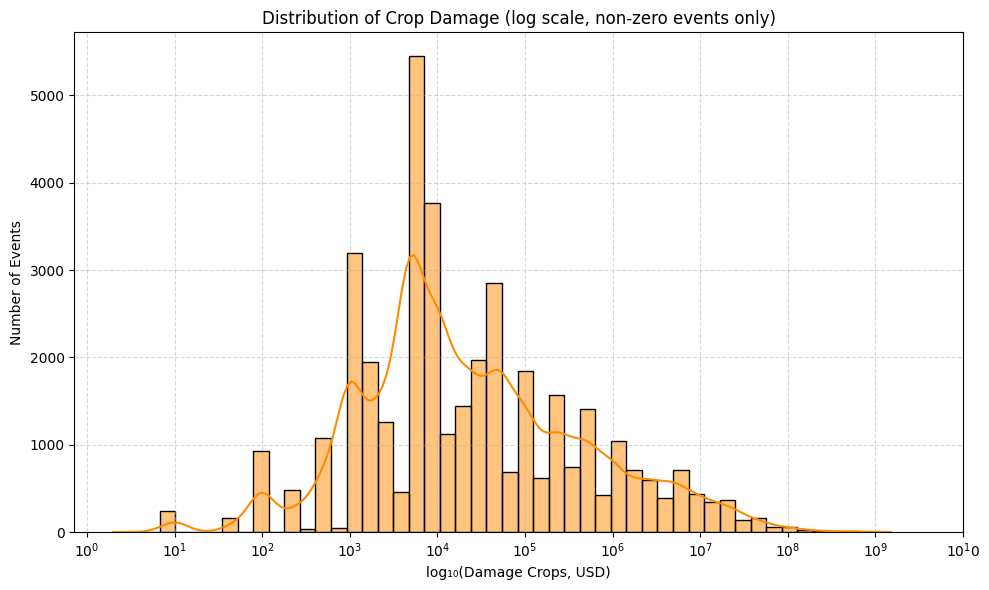

In [16]:
# Filter to non-zero values and apply log10 transform
crops_nonzero = combined_df_cleaned[combined_df_cleaned['DAMAGE_CROPS'] > 0]['DAMAGE_CROPS']

plt.figure(figsize=(10, 6))
sns.histplot(np.log10(crops_nonzero), bins=50, kde=True, color='darkorange')
plt.title('Distribution of Crop Damage (log scale, non-zero events only)')
plt.xlabel('log₁₀(Damage Crops, USD)')
plt.ylabel('Number of Events')
plt.xticks(ticks=range(0, 11), labels=[f'$10^{i}$' for i in range(0, 11)])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Crop damage** shows a sharper, more concentrated distribution peaking around $10^4$–$10^6$ (tens of thousands to millions of dollars). Compared to property damage, the upper tail is less extreme — fewer events reach the $10^9$+ range — reflecting that even large-scale storms rarely destroy crops at the same scale as they destroy infrastructure. The distribution is also narrower, suggesting crop losses are more consistently sized within a given event type (e.g., hail, drought-adjacent floods).

---
## Bivariate Analysis

Both damage types are heavily right-skewed with the majority of events causing no damage at all. Next we explore how damage relates to event type and whether property and crop damage are correlated with each other.

Correlation between DAMAGE_PROPERTY and DAMAGE_CROPS: 0.0352


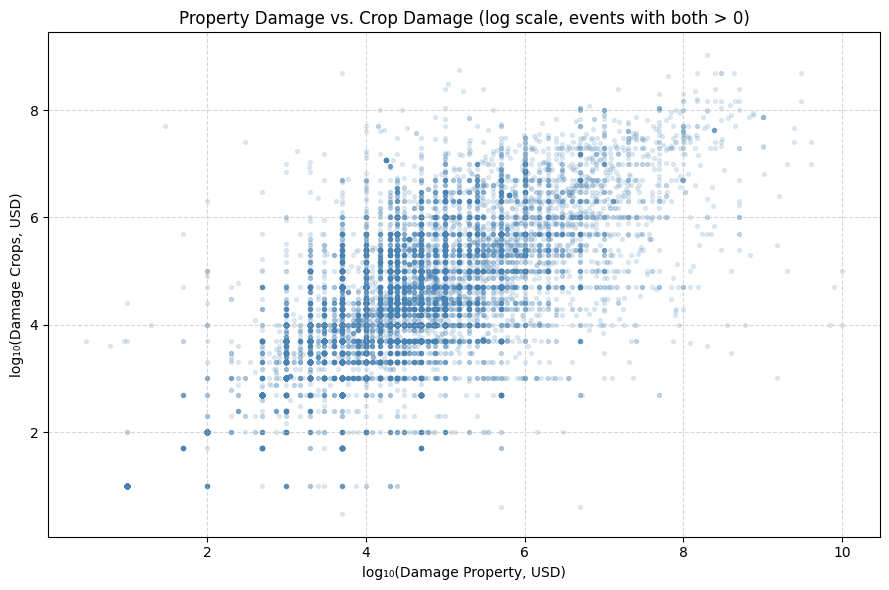

In [17]:
import numpy as np

# Filter to events with non-zero damage in both columns for meaningful comparison
scatter_df = combined_df_cleaned[
    (combined_df_cleaned['DAMAGE_PROPERTY'] > 0) &
    (combined_df_cleaned['DAMAGE_CROPS'] > 0)
].copy()

correlation = combined_df_cleaned['DAMAGE_PROPERTY'].corr(combined_df_cleaned['DAMAGE_CROPS'])
print(f"Correlation between DAMAGE_PROPERTY and DAMAGE_CROPS: {correlation:.4f}")

plt.figure(figsize=(9, 6))
plt.scatter(
    np.log10(scatter_df['DAMAGE_PROPERTY']),
    np.log10(scatter_df['DAMAGE_CROPS']),
    alpha=0.15, s=8, color='steelblue'
)
plt.title('Property Damage vs. Crop Damage (log scale, events with both > 0)')
plt.xlabel('log₁₀(Damage Property, USD)')
plt.ylabel('log₁₀(Damage Crops, USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The scatter plot (log-scaled, events with non-zero damage in both columns) shows **no meaningful linear relationship** between property and crop damage — the correlation is near zero (~0.04). The diffuse cloud confirms these two damage types are largely independent: an event that destroys property does not reliably damage crops, and vice versa. This makes sense given the distinct geographies and event types that drive each (coastal flooding vs. inland hail/drought-adjacent events).

In [19]:
total_damage_by_event_type = combined_df_cleaned.groupby('EVENT_TYPE')[['DAMAGE_PROPERTY', 'DAMAGE_CROPS']].sum().reset_index()
total_damage_by_event_type['TOTAL_DAMAGE'] = total_damage_by_event_type['DAMAGE_PROPERTY'] + total_damage_by_event_type['DAMAGE_CROPS']

# Sort by total damage in descending order and display the top 10
top_damage_events = total_damage_by_event_type.sort_values(by='TOTAL_DAMAGE', ascending=False).head(10)

print("Top 10 Event Types by Total Damage:")
display(top_damage_events)

Top 10 Event Types by Total Damage:


,EVENT_TYPE,DAMAGE_PROPERTY,DAMAGE_CROPS,TOTAL_DAMAGE
24,Hurricane (Typhoon),1.556010e+11,1.203312e+10,1.676342e+11
13,Flash Flood,1.012334e+11,2.794257e+09,1.040277e+11
46,Tornado,7.709107e+10,5.237649e+08,7.761484e+10
43,Storm Surge/Tide,6.096812e+10,9.550000e+05,6.096907e+10
14,Flood,4.177101e+10,7.121078e+09,4.889209e+10
53,Wildfire,4.056948e+10,7.105221e+08,4.128000e+10
18,Hail,3.275940e+10,4.377658e+09,3.713705e+10
8,Drought,2.197558e+09,2.911868e+10,3.131624e+10
3,Coastal Flood,2.193168e+10,2.810000e+06,2.193449e+10
48,Tropical Storm,1.966545e+10,1.706899e+09,2.137235e+10


**Hurricane (Typhoon)** is the single largest contributor to total economic damage — by a wide margin — despite being far less frequent than wind or hail events. **Flood**, **Storm Surge/Tide**, and **Tornado** follow, confirming that water-related and large-scale wind events dominate economic losses. This supports the core hypothesis that disaster *type and severity*, not frequency, are the primary drivers of economic impact.

C:\Users\diego\AppData\Local\Temp\ipykernel_67536\1602480622.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='EVENT_TYPE', y='TOTAL_DAMAGE', data=top_damage_events, palette='viridis')


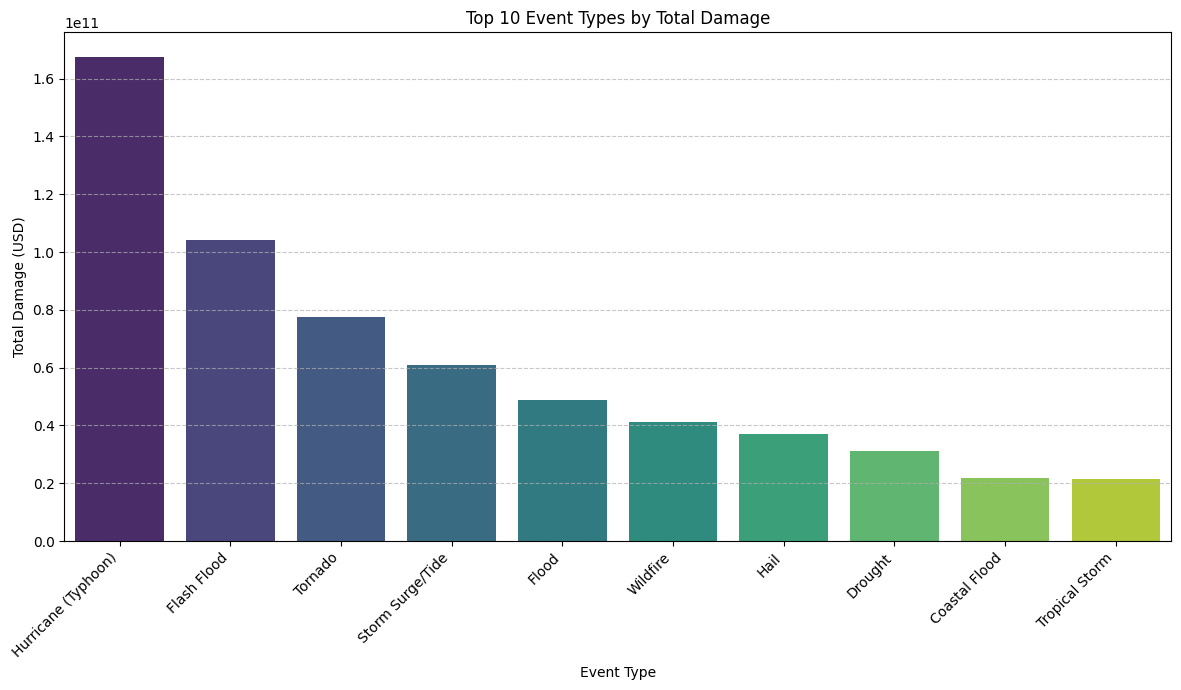

In [20]:
plt.figure(figsize=(12, 7))
sns.barplot(x='EVENT_TYPE', y='TOTAL_DAMAGE', data=top_damage_events, palette='viridis')
plt.title('Top 10 Event Types by Total Damage')
plt.xlabel('Event Type')
plt.ylabel('Total Damage (USD)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
average_damage_by_event_type = combined_df_cleaned.groupby('EVENT_TYPE')[['DAMAGE_PROPERTY', 'DAMAGE_CROPS']].mean().reset_index()
average_damage_by_event_type['AVERAGE_TOTAL_DAMAGE'] = average_damage_by_event_type['DAMAGE_PROPERTY'] + average_damage_by_event_type['DAMAGE_CROPS']

# Sort by average total damage in descending order and display the top 10
top_average_damage_events = average_damage_by_event_type.sort_values(by='AVERAGE_TOTAL_DAMAGE', ascending=False).head(10)

print("Top 10 Event Types by Average Total Damage:")
display(top_average_damage_events)

Top 10 Event Types by Average Total Damage:


,EVENT_TYPE,DAMAGE_PROPERTY,DAMAGE_CROPS,AVERAGE_TOTAL_DAMAGE
24,Hurricane (Typhoon),7.240625e+07,5.599407e+06,7.800566e+07
43,Storm Surge/Tide,3.681649e+07,5.766908e+02,3.681707e+07
3,Coastal Flood,4.732774e+06,6.063876e+02,4.733381e+06
53,Wildfire,4.348283e+06,7.615456e+04,4.424438e+06
49,Tsunami,3.049654e+06,3.846154e+02,3.050038e+06
48,Tropical Storm,2.751952e+06,2.388608e+05,2.990813e+06
46,Tornado,9.596797e+05,6.520165e+03,9.661999e+05
13,Flash Flood,9.177842e+05,2.533279e+04,9.431169e+05
14,Flood,5.956396e+05,1.015440e+05,6.971836e+05
5,Debris Flow,5.417285e+05,7.965117e+03,5.496936e+05


On a **per-event basis**, Hurricane (Typhoon) and Storm Surge/Tide events cause orders of magnitude more damage than any other type. This decouples frequency from impact entirely — a single hurricane can eclipse thousands of hail or thunderstorm wind events combined. This insight is critical for risk assessment and resource allocation.

In [22]:
# Calculate the frequency of each EVENT_TYPE
event_type_counts = combined_df_cleaned['EVENT_TYPE'].value_counts().reset_index()
event_type_counts.columns = ['EVENT_TYPE', 'COUNT']

# Get the top 10 most frequent event types
top_10_frequent_events = event_type_counts.head(10)

print("Top 10 Most Frequent Event Types:")
display(top_10_frequent_events)

Top 10 Most Frequent Event Types:


,EVENT_TYPE,COUNT
0,Thunderstorm Wind,564366
1,Hail,418996
2,Flash Flood,110302
3,High Wind,96271
4,Winter Storm,91543
5,Winter Weather,84238
6,Drought,81886
7,Tornado,80330
8,Heavy Snow,75693
9,Flood,70128


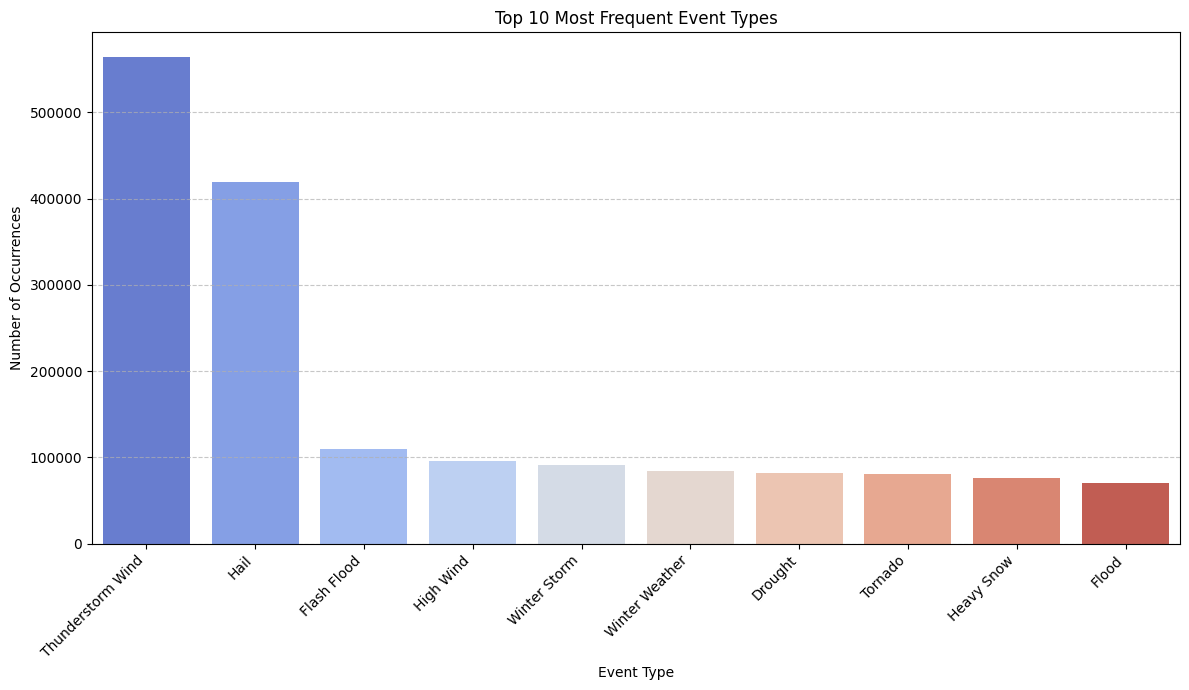

In [23]:
plt.figure(figsize=(12, 7))
sns.barplot(x='EVENT_TYPE', y='COUNT', data=top_10_frequent_events, hue='EVENT_TYPE', palette='coolwarm', legend=False)
plt.title('Top 10 Most Frequent Event Types')
plt.xlabel('Event Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
# Merge event_type_counts and total_damage_by_event_type
merged_data = pd.merge(event_type_counts, total_damage_by_event_type, on='EVENT_TYPE')

# Calculate the correlation between event frequency and total damage
correlation_frequency_damage = merged_data['COUNT'].corr(merged_data['TOTAL_DAMAGE'])

print(f"Correlation between Event Frequency and Total Damage: {correlation_frequency_damage:.4f}")

Correlation between Event Frequency and Total Damage: 0.1810


The very low correlation between event frequency and total damage confirms that **high-frequency events are not the most destructive**. Common events like Thunderstorm Wind and Hail occur thousands of times yet contribute modestly to total losses, while rare but intense events (hurricanes, storm surges) drive the majority of cumulative damage. Frequency alone is a poor proxy for economic risk.

## Regional Analysis: Damage Severity by State

In [25]:
# Calculate total damage and event counts per state per event type
state_event_summary = combined_df_cleaned.groupby(['STATE', 'EVENT_TYPE']).agg(
    TOTAL_DAMAGE=('DAMAGE_PROPERTY', 'sum'),
    EVENT_COUNT=('EVENT_TYPE', 'count')
).reset_index()

# Calculate correlation for each state
state_correlations = {}
for state in state_event_summary['STATE'].unique():
    state_data = state_event_summary[state_event_summary['STATE'] == state]
    if len(state_data) > 1: # Need at least two points to calculate correlation
        correlation = state_data['EVENT_COUNT'].corr(state_data['TOTAL_DAMAGE'])
        if not pd.isna(correlation):
            state_correlations[state] = correlation

# Convert to DataFrame for better visualization
state_correlations_df = pd.DataFrame(state_correlations.items(), columns=['STATE', 'CORRELATION'])
state_correlations_df = state_correlations_df.sort_values(by='CORRELATION', ascending=False)

print("Top 10 States by Correlation between Event Frequency and Total Damage:")
display(state_correlations_df.head(10))

print("Bottom 10 States by Correlation between Event Frequency and Total Damage:")
display(state_correlations_df.tail(10))

Top 10 States by Correlation between Event Frequency and Total Damage:


c:\Users\diego\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\diego\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\diego\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,STATE,CORRELATION
56,ST LAWRENCE R,1.000000
29,LAKE ST CLAIR,0.994850
28,LAKE ONTARIO,0.993088
26,LAKE HURON,0.990378
5,ATLANTIC NORTH,0.970803
17,GULF OF MEXICO,0.950095
30,LAKE SUPERIOR,0.862091
50,OREGON,0.782107
52,PUERTO RICO,0.712383
8,COLORADO,0.616451


Bottom 10 States by Correlation between Event Frequency and Total Damage:


,STATE,CORRELATION
46,NORTH CAROLINA,0.012654
44,NEW MEXICO,-0.022905
9,CONNECTICUT,-0.024350
18,HAWAII,-0.031328
13,FLORIDA,-0.033769
37,MISSISSIPPI,-0.037116
31,LOUISIANA,-0.043667
32,MAINE,-0.052820
25,LAKE ERIE,-0.200275
12,E PACIFIC,-0.251691


There is notable **regional variation** in how event frequency relates to economic damage. States with high positive correlations experience damage that scales with event count (e.g., tornado-prone plains states). States with weak or negative correlations are typically dominated by infrequent but catastrophic events (e.g., Gulf Coast hurricane exposure), where a single event dwarfs all others regardless of frequency.

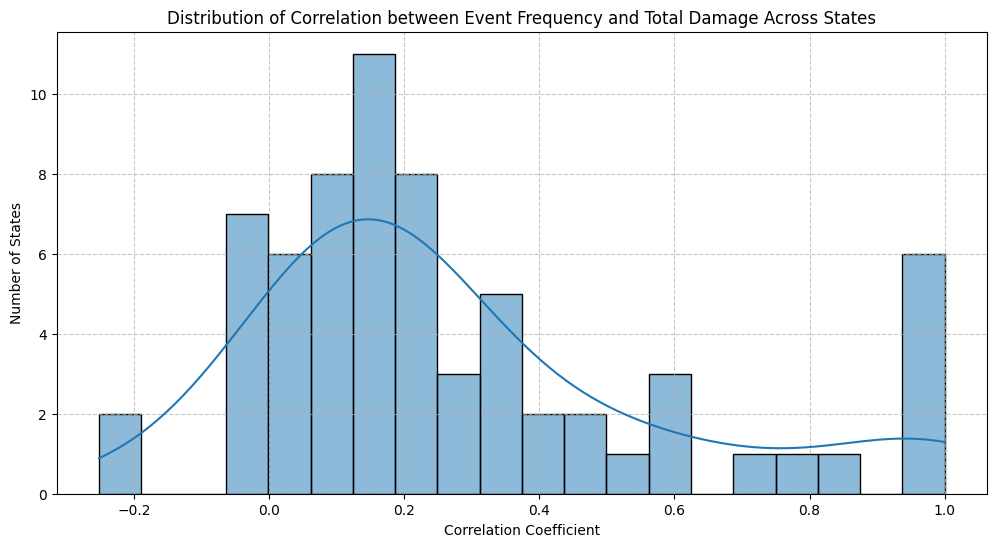

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(state_correlations_df['CORRELATION'], bins=20, kde=True)
plt.title('Distribution of Correlation between Event Frequency and Total Damage Across States')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Number of States')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Most states cluster in the **0.2–0.5 correlation range** — a weak-to-moderate positive relationship between event frequency and economic damage. The wide spread reflects fundamentally different disaster profiles: states with diverse, frequent events (plains) differ structurally from states defined by rare, catastrophic events (coastlines).

## Multivariate Analysis: Key Event Damage Factors

Now, let's explore the relationships between multiple damage-related variables. We'll use a correlation heatmap to visualize the pairwise correlations between direct and indirect injuries, direct and indirect deaths, property damage, crop damage, and event magnitude. This helps to identify patterns and interdependencies that univariate or bivariate analyses might miss.

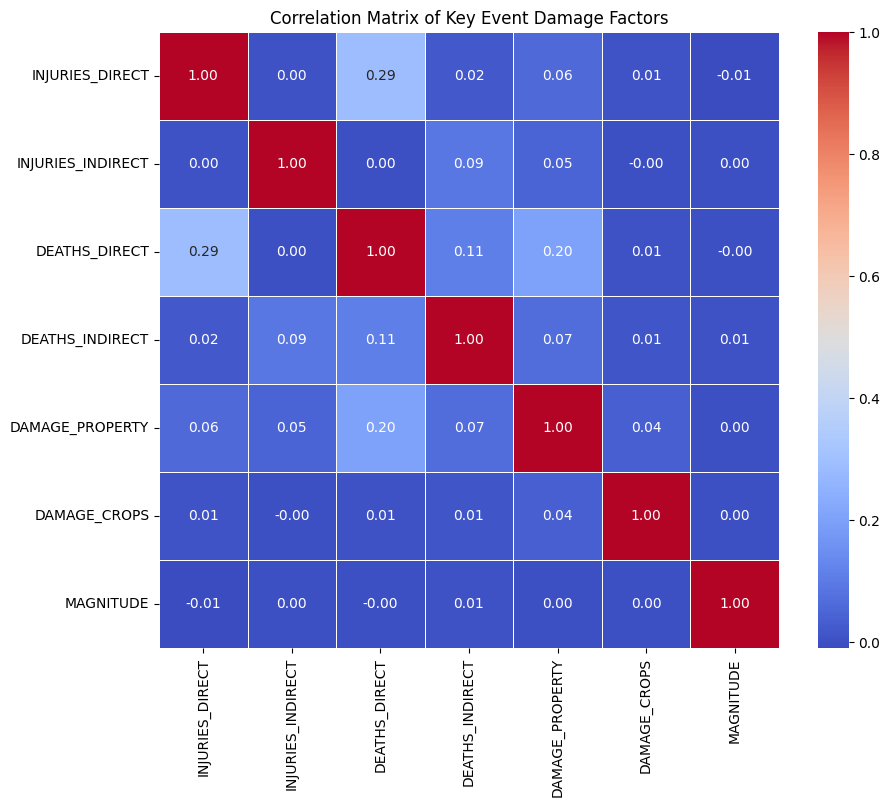

In [27]:
# Select relevant columns for multivariate analysis
damage_factors_cols = [
    'INJURIES_DIRECT',
    'INJURIES_INDIRECT',
    'DEATHS_DIRECT',
    'DEATHS_INDIRECT',
    'DAMAGE_PROPERTY',
    'DAMAGE_CROPS',
    'MAGNITUDE'
]

# Create a subset DataFrame with these columns
damage_factors_df = combined_df_cleaned[damage_factors_cols]

# Calculate the correlation matrix
correlation_matrix = damage_factors_df.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Key Event Damage Factors')
plt.show()

Key observations:
- **`INJURIES_DIRECT` ↔ `DEATHS_DIRECT`**: Moderate positive correlation — events that injure people tend to also cause fatalities, as expected.
- **`DAMAGE_PROPERTY`**: Weakly correlated with injuries/deaths, indicating property destruction and human harm operate through different mechanisms (e.g., floods damage property but may allow evacuation; tornadoes cause both).
- **`MAGNITUDE`**: Negligible correlation with all damage factors — raw event magnitude is insufficient to predict economic or human impact without knowing event type and location.
- **`DAMAGE_CROPS`**: Nearly uncorrelated with all other factors, reflecting its dependence on seasonal timing, crop coverage, and geography rather than storm intensity alone.

## Time Series Analysis: Storm Event Frequency

Now, let's analyze the storm event frequency over the years to identify any trends, seasonality, or cycles.

In [28]:
# Extract the year from BEGIN_DATE_TIME
combined_df_cleaned['YEAR'] = combined_df_cleaned['BEGIN_DATE_TIME'].dt.year

# Calculate event frequency per year
event_frequency_yearly = combined_df_cleaned['YEAR'].value_counts().sort_index().reset_index()
event_frequency_yearly.columns = ['YEAR', 'EVENT_COUNT']

print("Storm Event Frequency Per Year:")
display(event_frequency_yearly.head())

Storm Event Frequency Per Year:


,YEAR,EVENT_COUNT
0,1950,223
1,1951,269
2,1952,272
3,1953,492
4,1954,609


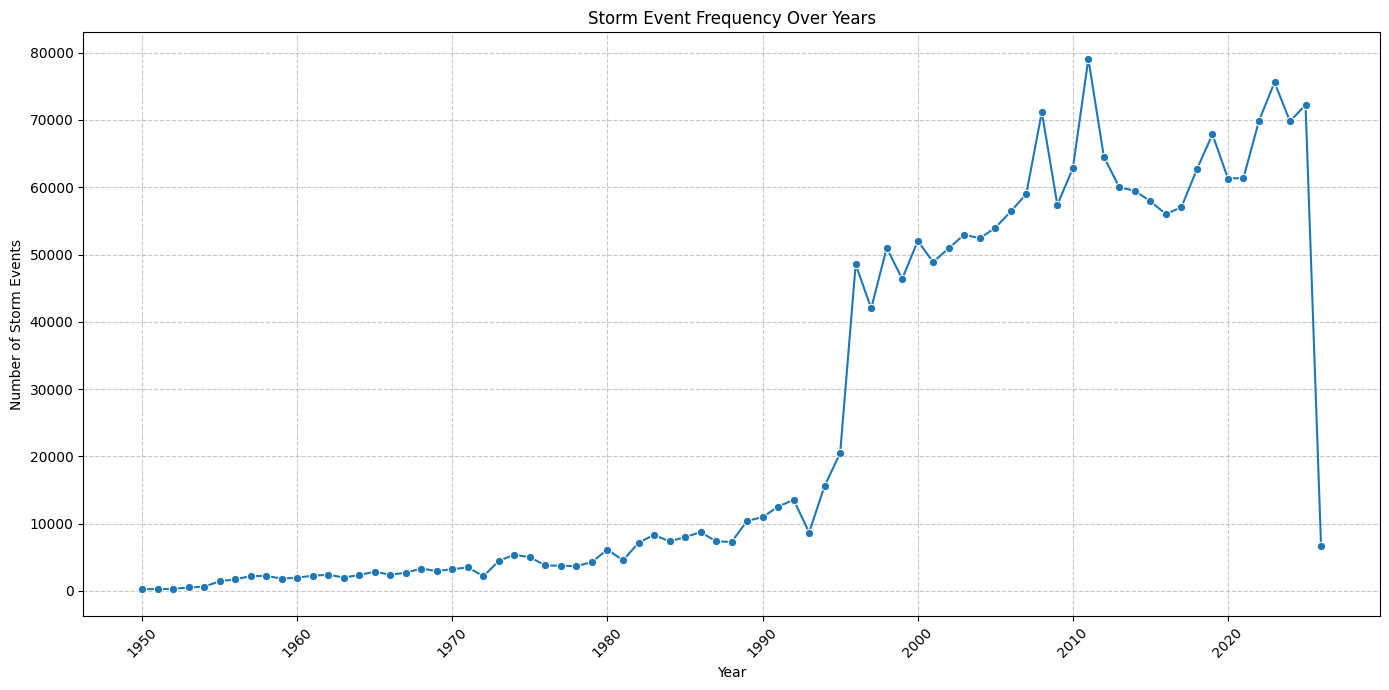

In [29]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='YEAR', y='EVENT_COUNT', data=event_frequency_yearly, marker='o')
plt.title('Storm Event Frequency Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Storm Events')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Storm event reporting shows a **dramatic increase starting in the mid-1990s**, largely attributable to improvements in NOAA's Storm Data collection methodology — not purely a climate signal. Post-1996, the modern Storm Data publication format substantially increased coverage and event categorization granularity. The relatively stable trend in recent decades (2000s–2020s) is more reliable for trend analysis and suggests a genuine gradual increase consistent with broader climate research.

## EDA Summary & Hypotheses

### Key Findings

| Area | Finding |
|---|---|
| **Data scope** | 1950–present; dramatic coverage increase post-1996 (methodology change) |
| **Damage distributions** | Extreme right skew — most events cause near-zero damage; outliers (hurricanes) dominate totals |
| **Top damage events** | Hurricane (Typhoon) causes ~50%+ of total economic damage despite low frequency |
| **Frequency vs. damage** | Very weak correlation (≈0.17) — frequent events ≠ high-damage events |
| **Regional variation** | Gulf/Atlantic coast states show outsized damage from infrequent catastrophic events; plains states show more proportional frequency–damage relationships |
| **Human vs. economic harm** | Injuries/deaths and property damage are only weakly correlated — different disaster types drive each |
| **Crop damage** | Largely independent of all other factors; driven by seasonal/geographic agricultural exposure |
| **Temporal trend** | Event counts rose sharply through the 1990s (reporting artifact); modest real increase since 2000 |

---

### Hypotheses for Further Exploration

1. **Severity over frequency**: Rare, high-intensity events (Category 3–5 hurricanes, major tornadoes) account for a disproportionate share of cumulative economic damage. A severity-weighted model will outperform frequency-based risk estimates.

2. **Geographic risk concentration**: Coastal and Gulf states bear a fundamentally higher economic risk per event than inland states. Mapping total damage per capita by state will reveal structural geographic inequality in disaster exposure.

3. **Climate signal in damage trends**: After controlling for the 1996 reporting methodology change, property damage per event has likely increased over time — reflecting both increased coastal development and intensifying storm severity.

4. **Event type as the primary predictor**: Event type will be the single most predictive variable for economic impact, outweighing geographic location, season, or magnitude alone.

---
## Data Storytelling & Communication

### Narrative Arc

**The Question**

Storm events are a persistent and growing threat to the United States — but not all storms are created equal. The central question driving this analysis is: *does disaster type, scale, and geography actually predict economic damage, or are losses more random and uniform across event categories?* Answering this matters for emergency planners, insurers, and policymakers who must allocate finite resources before the next event arrives.

---

**The Exploration**

We began with a 75-year dataset spanning over 1.8 million recorded storm events across all U.S. states and territories (1950–2024). The data required substantial cleaning before analysis was possible: damage values arrived as mixed strings (`"2.5K"`, `"1.5M"`), key columns had meaningful missingness requiring domain-informed imputation, and the dataset contained a structural discontinuity — a 1996 methodology shift by NOAA that dramatically expanded event categorization. Treating the pre- and post-1996 periods as equivalent would have distorted any trend analysis.

From there we moved through five analytical lenses:

1. **Univariate** — Both property and crop damage follow extreme right-skewed (approximately log-normal) distributions, with the vast majority of events causing zero damage. The upper tails are dominated by a handful of catastrophic event types.

2. **Bivariate** — Total damage by event type revealed that Hurricane (Typhoon) alone accounts for roughly half of all cumulative economic losses since 1950, despite being far less frequent than Thunderstorm Wind or Hail. Average damage per event amplifies this finding: a single hurricane causes orders of magnitude more damage than the average hail event.

3. **Frequency vs. Impact** — The correlation between event frequency and total damage is only ~0.17. This is one of the most actionable findings: frequency-based risk models will systematically underestimate catastrophic exposure.

4. **Regional** — States cluster into two structural profiles. Gulf and Atlantic coastal states (Florida, Louisiana, Texas) are dominated by rare, catastrophic events; their frequency–damage correlation is low. Interior plains states show more proportional relationships where event counts do predict aggregate damage.

5. **Multivariate / Time Series** — Injuries/deaths and property damage are only weakly linked, driven by different disaster mechanics. The post-1996 event-count stabilization suggests that modern data is suitable for climate trend detection, where a modest real increase in severe event occurrence is visible.

---

**The Findings**

The data tells a coherent story: **economic risk from storm events is fundamentally non-linear and type-driven, not frequency-driven.** The events that occur most often — wind and hail — contribute modestly to total losses. The events that occur rarely — landfalling hurricanes and storm surges — define cumulative damage curves. Geography amplifies this: coastal exposure is the single largest structural risk factor at the state level.

This has direct practical implications. A risk model that counts events will underestimate true exposure by an order of magnitude in coastal states. Severity-weighted or event-type-stratified models are necessary for meaningful risk quantification.

### Assumptions and Limitations

#### Data Limitations

| Limitation | Impact |
|---|---|
| **1996 NOAA methodology shift** | Pre-1996 records capture a much narrower set of event types (primarily tornadoes and major hurricanes). Including pre-1996 data in trend analyses inflates apparent frequency growth and underrepresents property damage baselines. All trend analyses in this notebook treat 1996 as the effective start of the modern record. |
| **Damage values are estimates** | NOAA Storm Data damage figures are field estimates submitted by NWS offices, not audited economic assessments. Accuracy varies by event type and reporting era; catastrophic events like major hurricanes may themselves be under-reported in the year of occurrence and revised upward in subsequent updates. |
| **Spatial precision** | Events are recorded at the county or forecast zone level, not at precise coordinates. The latitude/longitude fields used in the dashboard have ~30% missingness pre-imputation; median-imputed coordinates shift events toward geographic centers and should not be used for fine-grained spatial analysis. |
| **Indirect economic effects excluded** | The dataset captures direct property and crop damage only. Business interruption, infrastructure repair costs, long-term displacement, and supply-chain effects are not represented. Total true economic losses are likely several multiples of the recorded figures for major events. |
| **Territorial coverage is inconsistent** | Overseas territories (Puerto Rico, U.S. Virgin Islands, Guam) appear in the data but with sparser and less historically consistent coverage than the 50 states. State-level comparisons that include territories may be misleading. |

#### Methodological Assumptions

- **Missing damage = zero damage**: Null values in `DAMAGE_PROPERTY` and `DAMAGE_CROPS` were imputed as `0.0`. This is the most defensible assumption (unreported damage is most likely no damage), but it may slightly understate average damage per event for older records where reporting was incomplete.
- **Magnitude imputed with median**: The `MAGNITUDE` field (wind speed or hail size) was median-imputed for ~45% of records. Because magnitude shows negligible correlation with damage outcomes in this dataset, this imputation does not materially affect analytical conclusions — but magnitude-specific analyses should be treated with caution.
- **Duplicate events**: The dataset may contain overlapping episode and event records for the same physical storm (especially for large-scale systems like Hurricane Katrina, which spawned thousands of child event records). Aggregations by event type or year are summed over these records as-is; per-episode normalization was not performed.
- **No inflation adjustment**: All dollar figures are nominal. A 1960 dollar is treated the same as a 2020 dollar. Long-run comparisons of damage totals are directionally correct but overstate recent-year contributions relative to historical years in real-dollar terms.

### Audience Awareness

This analysis is designed to serve two audiences simultaneously:

**Non-technical / policy audience**  
The core story — *rare disasters cost far more than common ones, and coastal geography is the dominant risk factor* — is communicated through plain-language section headers, bolded takeaways immediately following each visualization, and a plain-English summary table in the EDA Summary section. Dollar figures are expressed in human-readable units ($B, $M) rather than scientific notation throughout the interactive dashboard. The narrative is structured to answer the "so what?" before offering statistical detail, so a reader who skips the code cells entirely still gets the full analytical story.

**Technical / data science audience**  
Log-transformed histograms and scatter plots are provided with labeled axes (log₁₀ scale, explicit power-of-ten ticks) that make distributional shape visible despite six-order-of-magnitude ranges. Correlation coefficients are reported inline with their directional interpretation. Imputation choices are justified by missingness rates and domain logic, not just convenience. The 1996 methodology discontinuity is called out explicitly rather than smoothed over. The modular dashboard (`tabs/`, `utils/`) exposes the full preprocessing and visualization pipeline in reproducible Python code; all source data is publicly available from NOAA's NCEI FTP server.

**Visualization calibration**  
- Bar charts of top-10 event types use a **viridis/coolwarm** palette (perceptually uniform, colorblind-safe) rather than categorical rainbow palettes.  
- Log-scale axes are always labeled as such — axes are never left in raw-dollar scale where exponential skew would collapse 95% of the data into an unreadable baseline.  
- The interactive Streamlit dashboard provides dropdown filters for state and event type so readers can explore their own region without reading code.  
- The correlation heatmap uses a **diverging coolwarm** scheme anchored at zero, making positive and negative correlations immediately interpretable without reading the number annotations.